In [1]:
import requests
import pandas as pd

#Lagos
lat, lon = 6.5244, 3.3792

# Open-Meteo ARCHIVE API
url = "https://archive-api.open-meteo.com/v1/archive"
params = {
    "latitude": lat,
    "longitude": lon,
    "start_date": "2015-01-01",
    "end_date": "2024-12-31",
    "hourly": "temperature_2m,relative_humidity_2m,precipitation,surface_pressure,wind_speed_10m",
    "timezone": "Africa/Lagos"
}

r = requests.get(url, params=params, timeout=60)
data = r.json()


df = pd.DataFrame(data["hourly"])
df["time"] = pd.to_datetime(df["time"])

print("Rows:", len(df))
print("Date range:", df["time"].min(), "to", df["time"].max())
print(df.head())
print("\nMissing values per column:")
print(df.isna().sum())

Rows: 87672
Date range: 2015-01-01 00:00:00 to 2024-12-31 23:00:00
                 time  temperature_2m  relative_humidity_2m  precipitation  \
0 2015-01-01 00:00:00            26.1                    81            0.0   
1 2015-01-01 01:00:00            25.1                    88            0.0   
2 2015-01-01 02:00:00            25.0                    88            0.0   
3 2015-01-01 03:00:00            25.3                    87            0.0   
4 2015-01-01 04:00:00            24.7                    91            0.0   

   surface_pressure  wind_speed_10m  
0            1010.4             8.2  
1            1010.2             7.9  
2            1009.8             7.0  
3            1009.7             8.2  
4            1009.8             8.9  

Missing values per column:
time                    0
temperature_2m          0
relative_humidity_2m    0
precipitation           0
surface_pressure        0
wind_speed_10m          0
dtype: int64


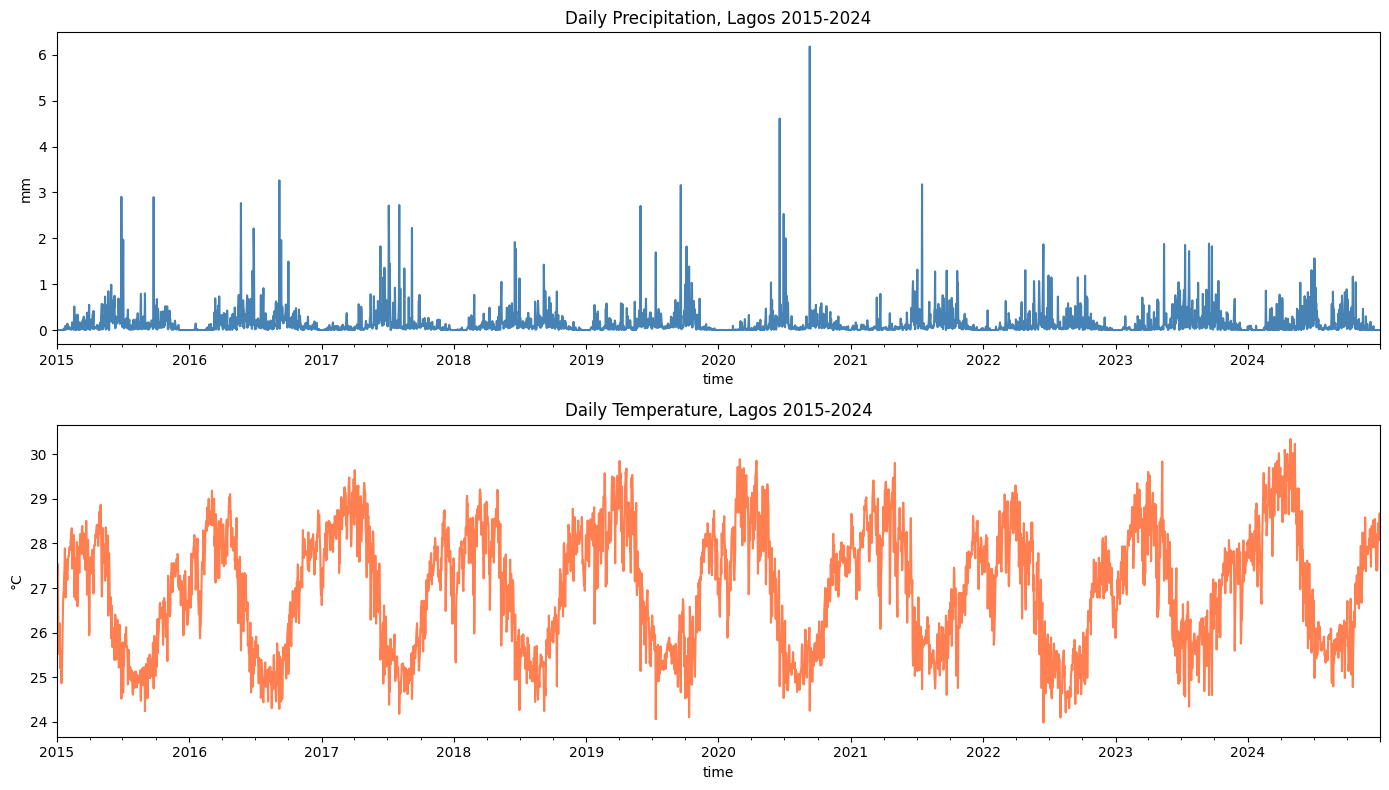

Average precipitation by month:
month
1     0.022218
2     0.047953
3     0.101129
4     0.101667
5     0.189032
6     0.353194
7     0.244328
8     0.157957
9     0.305486
10    0.228266
11    0.085125
12    0.019704
Name: precipitation, dtype: float64


In [2]:
import matplotlib.pyplot as plt

# set time as the index so plotting is clean
df = df.set_index("time")

# resample hourly data to daily averages so the yearly pattern is visible
daily = df.resample("D").mean()

# plot precipitation and temperature over the full 10 years
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

daily["precipitation"].plot(ax=axes[0], title="Daily Precipitation, Lagos 2015-2024", color="steelblue")
axes[0].set_ylabel("mm")

daily["temperature_2m"].plot(ax=axes[1], title="Daily Temperature, Lagos 2015-2024", color="coral")
axes[1].set_ylabel("°C")

plt.tight_layout()
plt.show()

# also look at the average rainfall by month — the rainy season signature
df["month"] = df.index.month
monthly_rain = df.groupby("month")["precipitation"].mean()
print("Average precipitation by month:")
print(monthly_rain)

In [3]:
# start from your hourly df — collapse to daily averages first
daily = df.resample("D").mean(numeric_only=True)

# we'll forecast temperature; keep the columns we need
data = daily[["temperature_2m", "relative_humidity_2m", "precipitation", "surface_pressure"]].copy()

# --- LAG FEATURES: past values as predictors ---
data["temp_lag1"] = data["temperature_2m"].shift(1)   # yesterday's temp
data["temp_lag2"] = data["temperature_2m"].shift(2)   # 2 days ago
data["temp_lag7"] = data["temperature_2m"].shift(7)   # a week ago

# --- ROLLING AVERAGE: smoothed recent trend ---
data["temp_roll7"] = data["temperature_2m"].shift(1).rolling(7).mean()  # avg of last 7 days

# --- CALENDAR FEATURES: capture season ---
data["month"] = data.index.month
data["dayofyear"] = data.index.dayofyear

# --- THE TARGET: tomorrow's temperature (what we predict) ---
data["target_temp"] = data["temperature_2m"].shift(-1)

# the shifts create empty cells at the edges — drop those rows
data = data.dropna()

print("Shape:", data.shape)
print(data[["temperature_2m", "temp_lag1", "temp_lag7", "temp_roll7", "month", "target_temp"]].head())

Shape: (3645, 11)
            temperature_2m  temp_lag1  temp_lag7  temp_roll7  month  \
time                                                                  
2015-01-08       25.775000  25.662500  27.341667   26.613690      1   
2015-01-09       26.204167  25.775000  27.316667   26.389881      1   
2015-01-10       25.395833  26.204167  27.541667   26.230952      1   
2015-01-11       25.191667  25.395833  26.929167   25.924405      1   
2015-01-12       25.587500  25.191667  25.983333   25.676190      1   

            target_temp  
time                     
2015-01-08    26.204167  
2015-01-09    25.395833  
2015-01-10    25.191667  
2015-01-11    25.587500  
2015-01-12    24.862500  


In [4]:
feature_cols = ["temp_lag1", "temp_lag2", "temp_lag7", "temp_roll7",
                "relative_humidity_2m", "surface_pressure", "month", "dayofyear"]
X = data[feature_cols]
y = data["target_temp"]


split_date = "2023-01-01"
X_train, X_test = X[X.index < split_date], X[X.index >= split_date]
y_train, y_test = y[y.index < split_date], y[y.index >= split_date]

print("Train:", X_train.shape, "->", X_train.index.min().date(), "to", X_train.index.max().date())
print("Test: ", X_test.shape, "->", X_test.index.min().date(), "to", X_test.index.max().date())

Train: (2915, 8) -> 2015-01-08 to 2022-12-31
Test:  (730, 8) -> 2023-01-01 to 2024-12-30


In [5]:
import numpy as np
from sklearn.metrics import mean_absolute_error

# BASELINE: predict tomorrow = today (persistence)
baseline_pred = X_test["temp_lag1"].values  # "today's temp" as the guess for tomorrow

baseline_pred = data.loc[X_test.index, "temperature_2m"].values

baseline_mae = mean_absolute_error(y_test, baseline_pred)
print(f"Baseline (persistence) MAE: {baseline_mae:.3f} °C")

Baseline (persistence) MAE: 0.426 °C


In [6]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score


model = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

preds = model.predict(X_test)

mae = mean_absolute_error(y_test, preds)
r2 = r2_score(y_test, preds)

print(f"Random Forest MAE: {mae:.3f} °C")
print(f"Baseline MAE:      {baseline_mae:.3f} °C")
print(f"R² score:          {r2:.3f}")

Random Forest MAE: 0.464 °C
Baseline MAE:      0.426 °C
R² score:          0.782


In [7]:
# NEW TARGET
data["target_temp_7d"] = data["temperature_2m"].shift(-7)
data_7d = data.dropna(subset=["target_temp_7d"]).copy()

# 7-day horizon
X7 = data_7d[feature_cols]
y7 = data_7d["target_temp_7d"]

# same time-based split
X7_train, X7_test = X7[X7.index < split_date], X7[X7.index >= split_date]
y7_train, y7_test = y7[y7.index < split_date], y7[y7.index >= split_date]

# BASELINE
baseline_7d = data_7d.loc[X7_test.index, "temperature_2m"].values
baseline_7d_mae = mean_absolute_error(y7_test, baseline_7d)

# at 7 days
model_7d = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
model_7d.fit(X7_train, y7_train)
preds_7d = model_7d.predict(X7_test)
model_7d_mae = mean_absolute_error(y7_test, preds_7d)

print(f"--- 7-DAY HORIZON ---")
print(f"Baseline (persistence) MAE: {baseline_7d_mae:.3f} °C")
print(f"Random Forest MAE:          {model_7d_mae:.3f} °C")
print(f"R²:                         {r2_score(y7_test, preds_7d):.3f}")

--- 7-DAY HORIZON ---
Baseline (persistence) MAE: 0.601 °C
Random Forest MAE:          0.549 °C
R²:                         0.714


 1-day  baseline 0.427  |  model 0.465
 2-day  baseline 0.538  |  model 0.507
 3-day  baseline 0.542  |  model 0.506
 5-day  baseline 0.585  |  model 0.536
 7-day  baseline 0.601  |  model 0.549
10-day  baseline 0.618  |  model 0.547
14-day  baseline 0.667  |  model 0.546
21-day  baseline 0.731  |  model 0.563


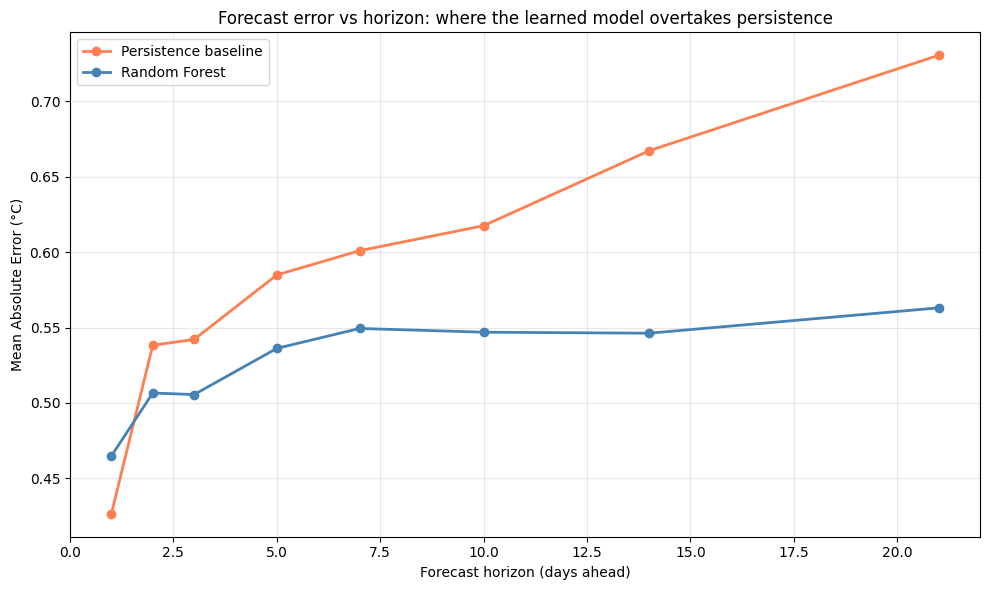

In [8]:
import matplotlib.pyplot as plt

horizons = [1, 2, 3, 5, 7, 10, 14, 21]
baseline_maes = []
model_maes = []

for h in horizons:
    # target = temperature h days ahead
    d = data.copy()
    d["target_h"] = d["temperature_2m"].shift(-h)
    d = d.dropna(subset=["target_h"])

    Xh = d[feature_cols]
    yh = d["target_h"]
    Xh_train, Xh_test = Xh[Xh.index < split_date], Xh[Xh.index >= split_date]
    yh_train, yh_test = yh[yh.index < split_date], yh[yh.index >= split_date]

    # persistence baseline: "h days from now = today"
    base_pred = d.loc[Xh_test.index, "temperature_2m"].values
    baseline_maes.append(mean_absolute_error(yh_test, base_pred))

    # random forest
    m = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
    m.fit(Xh_train, yh_train)
    model_maes.append(mean_absolute_error(yh_test, m.predict(Xh_test)))

    print(f"{h:>2}-day  baseline {baseline_maes[-1]:.3f}  |  model {model_maes[-1]:.3f}")

# plot the two lines
plt.figure(figsize=(10, 6))
plt.plot(horizons, baseline_maes, "o-", label="Persistence baseline", color="coral", linewidth=2)
plt.plot(horizons, model_maes, "o-", label="Random Forest", color="steelblue", linewidth=2)
plt.xlabel("Forecast horizon (days ahead)")
plt.ylabel("Mean Absolute Error (°C)")
plt.title("Forecast error vs horizon: where the learned model overtakes persistence")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
import requests
import pandas as pd


lat, lon = 6.5244, 3.3792
url = "https://api.open-meteo.com/v1/forecast"
params = {
    "latitude": lat, "longitude": lon,
    "hourly": "temperature_2m,relative_humidity_2m,precipitation,surface_pressure",
    "timezone": "Africa/Lagos",
    "past_days": 30, "forecast_days": 1
}
live = requests.get(url, params=params, timeout=30).json()

# to daily averages, same as training
live_df = pd.DataFrame(live["hourly"])
live_df["time"] = pd.to_datetime(live_df["time"])
live_df = live_df.set_index("time").resample("D").mean(numeric_only=True)


latest = live_df.iloc[-1]   # most recent complete day
features_live = pd.DataFrame([{
    "temp_lag1":  live_df["temperature_2m"].iloc[-1],
    "temp_lag2":  live_df["temperature_2m"].iloc[-2],
    "temp_lag7":  live_df["temperature_2m"].iloc[-7],
    "temp_roll7": live_df["temperature_2m"].iloc[-7:].mean(),
    "relative_humidity_2m": live_df["relative_humidity_2m"].iloc[-1],
    "surface_pressure": live_df["surface_pressure"].iloc[-1],
    "month": live_df.index[-1].month,
    "dayofyear": live_df.index[-1].dayofyear,
}])[feature_cols]

# predict tomorrow using your 1-day model (the original `model`)
tomorrow_temp = model.predict(features_live)[0]

print(f"Most recent day: {live_df.index[-1].date()}")
print(f"Today's avg temp: {live_df['temperature_2m'].iloc[-1]:.2f} °C")
print(f"MODEL FORECAST for tomorrow: {tomorrow_temp:.2f} °C")

Most recent day: 2026-06-26
Today's avg temp: 26.67 °C
MODEL FORECAST for tomorrow: 26.02 °C


In [10]:
import joblib
joblib.dump(model, "lagos_temp_model.joblib")
# reload later: model = joblib.load("lagos_temp_model.joblib")

['lagos_temp_model.joblib']

saved


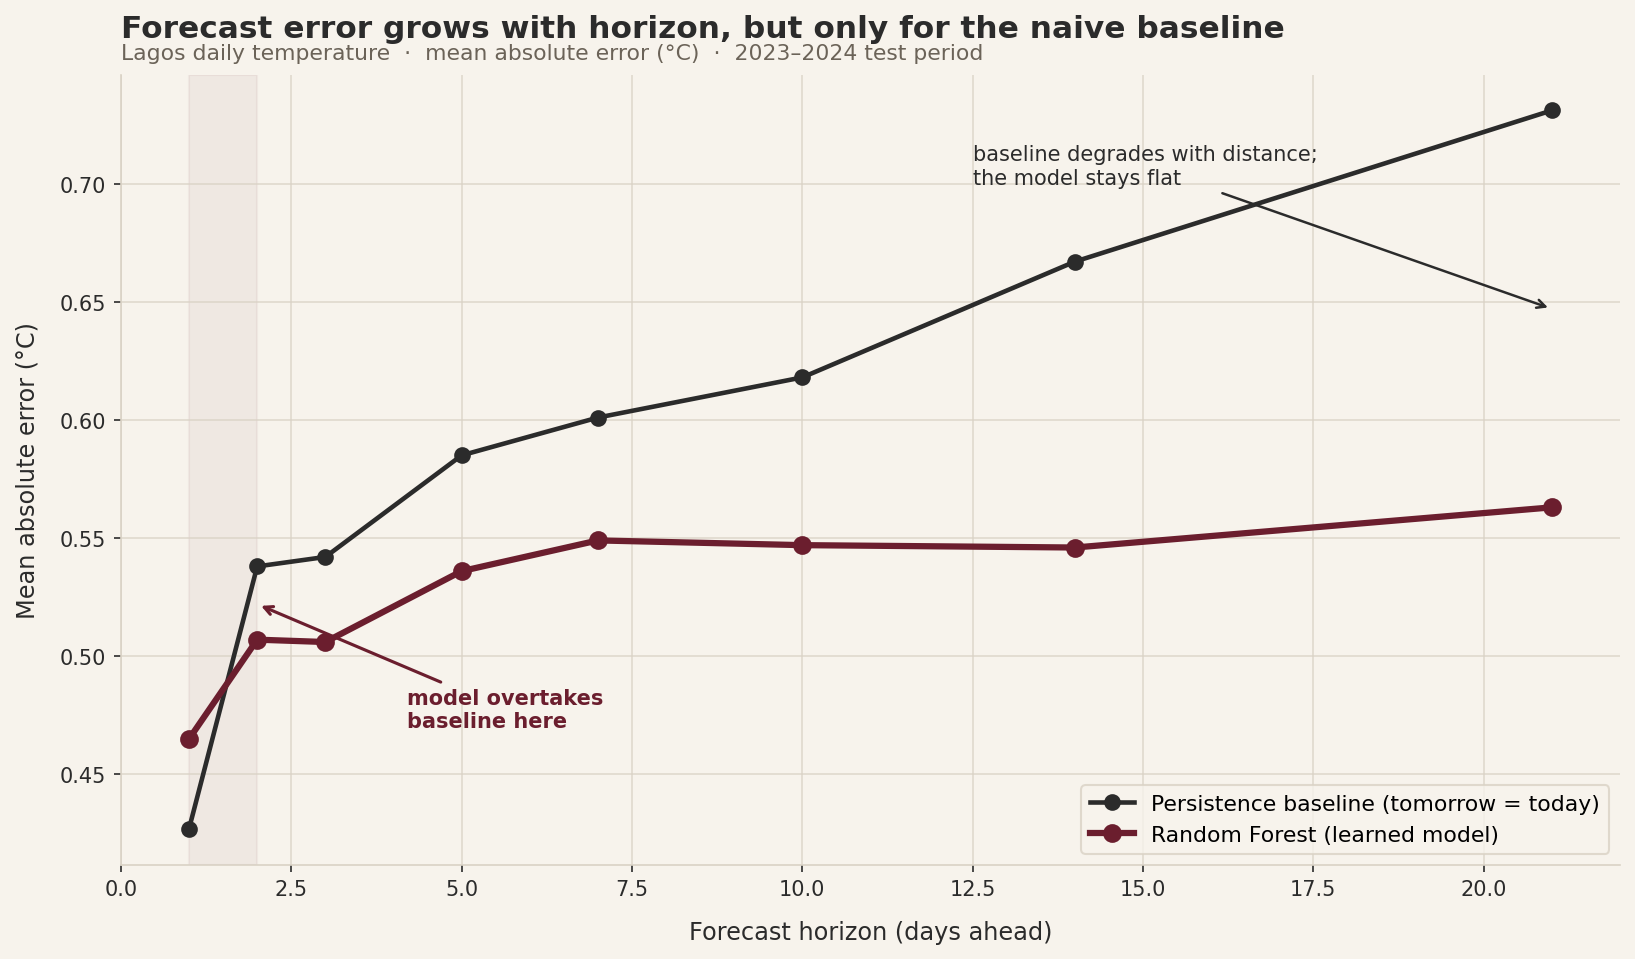

In [12]:
import matplotlib.pyplot as plt
from matplotlib import font_manager
import matplotlib as mpl


IVORY     = "#F7F3EC"
CHARCOAL  = "#2B2B2B"
BURGUNDY  = "#6B1E2E"
GRID      = "#D9D2C5"


horizons       = [1, 2, 3, 5, 7, 10, 14, 21]
baseline_maes  = [0.427, 0.538, 0.542, 0.585, 0.601, 0.618, 0.667, 0.731]
model_maes     = [0.465, 0.507, 0.506, 0.536, 0.549, 0.547, 0.546, 0.563]


mpl.rcParams["font.family"] = "DejaVu Sans"   # clean sans; swap for your brand font locally
fig, ax = plt.subplots(figsize=(11, 6.5), dpi=150)
fig.patch.set_facecolor(IVORY)
ax.set_facecolor(IVORY)


ax.plot(horizons, baseline_maes, "o-", color=CHARCOAL, linewidth=2.2,
        markersize=7, label="Persistence baseline (tomorrow = today)")
ax.plot(horizons, model_maes, "o-", color=BURGUNDY, linewidth=3,
        markersize=8, label="Random Forest (learned model)")


ax.axvspan(1, 2, color=BURGUNDY, alpha=0.05)
ax.annotate("model overtakes\nbaseline here",
            xy=(2, 0.522), xytext=(4.2, 0.47),
            fontsize=10, color=BURGUNDY, fontweight="bold",
            arrowprops=dict(arrowstyle="->", color=BURGUNDY, lw=1.5))


ax.annotate("baseline degrades with distance;\nthe model stays flat",
            xy=(21, 0.647), xytext=(12.5, 0.70),
            fontsize=10, color=CHARCOAL,
            arrowprops=dict(arrowstyle="->", color=CHARCOAL, lw=1.2))


ax.set_title("Forecast error grows with horizon, but only for the naive baseline",
             fontsize=15, fontweight="bold", color=CHARCOAL, pad=18, loc="left")
ax.text(0, 1.02, "Lagos daily temperature  ·  mean absolute error (°C)  ·  2023–2024 test period",
        transform=ax.transAxes, fontsize=10.5, color="#6B6358")

ax.set_xlabel("Forecast horizon (days ahead)", fontsize=11.5, color=CHARCOAL, labelpad=10)
ax.set_ylabel("Mean absolute error (°C)", fontsize=11.5, color=CHARCOAL, labelpad=10)


ax.grid(True, color=GRID, linewidth=0.8, alpha=0.8)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
for spine in ["left", "bottom"]:
    ax.spines[spine].set_color(GRID)
ax.tick_params(colors=CHARCOAL)


leg = ax.legend(loc="lower right", frameon=True, fontsize=10.5)
leg.get_frame().set_facecolor(IVORY)
leg.get_frame().set_edgecolor(GRID)

plt.tight_layout()
plt.savefig("/content/horizon_chart_styled.png", facecolor=IVORY, bbox_inches="tight")
print("saved")